1. Создайте систему для отправки сообщений через разные каналы (Email, SMS). У каждого канала свой формат подготовки текста. Нужно вести лог всех отправленных сообщений, используя статический метод для генерации уникального ID сообщения.

PS в задачах намеренно будут абстрактные классы, статические методы и композиция, не игнорировать их!!
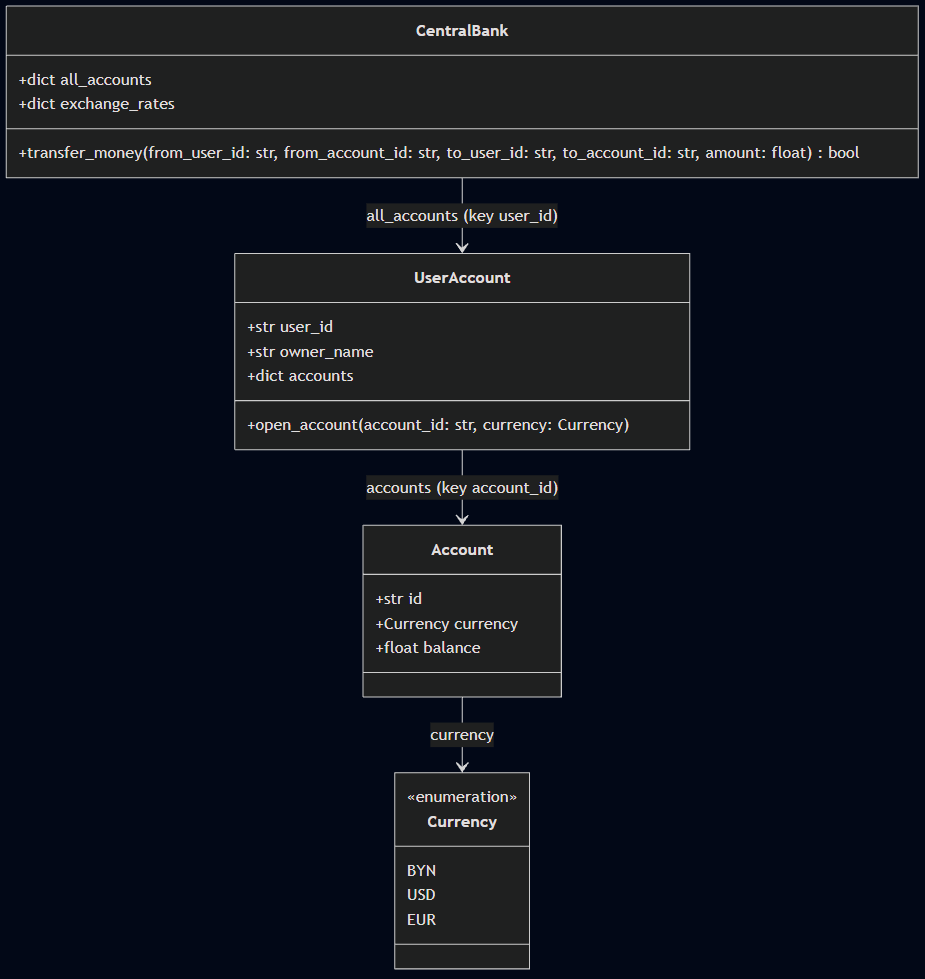

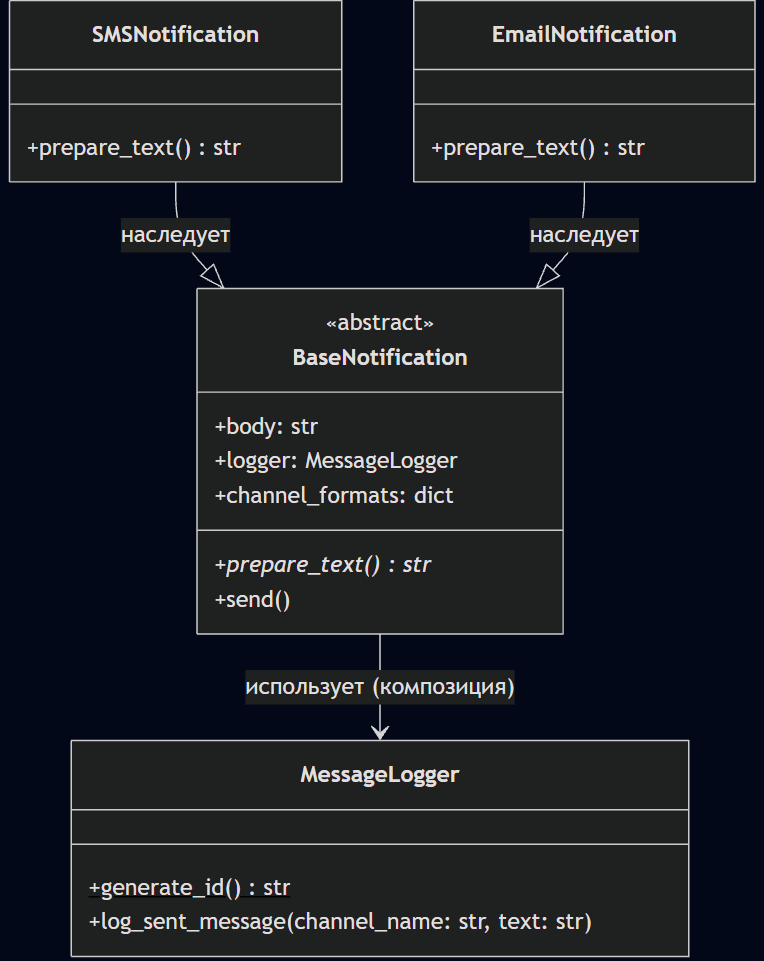

In [12]:
from abc import ABC, abstractmethod
import uuid
from datetime import datetime

# логирование + присваивание уникального id сообщению через статический метод + строки документации
class MessageLogger:
    @staticmethod
    def generate_id() -> str:
        """Статический метод для генерации уникального ID"""
        return str(uuid.uuid4())

    def log_sent_message(self, channel_name: str, text: str):
        """Метод для логирования"""
        msg_id = self.generate_id()
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        print(f"[{timestamp}] [ID: {msg_id}] Направлено в {channel_name}: {text}")

# базовый абстрактный класс(шаблон)
class BaseNotification(ABC):
# используем логгер, но не наследуемся от него, в том числе может использовать любой другой логгер
    def __init__(self, body: str, logger: MessageLogger = None):
        self.body = body
        # присваиваем стандартный логгер, если мы не получали логгер извне
        self.logger = logger if logger is not None else MessageLogger()
        # словарь с конфигурацией каналов
        self.channel_formats = {
            "SMS": "Plain Text (Max 160 chars)",
            "Email": "HTML"
        }
    # абстрактный метод для всех видов отправки и их форматирования(декларация для дальнейшего использования)
    # + строка документации
    @abstractmethod
    def prepare_text(self) -> str:
        """У каждого канала уникальные подготовка к форматированию и само форматирование текста"""
        pass

    def send(self):
        #готовим текст, вызывая метод текущего класса
        prepared_text = self.prepare_text()
        #определяем имя канала получая его извне
        channel_name = self.__class__.__name__
        # предаем данные в логгер для записи
        self.logger.log_sent_message(channel_name, prepared_text)

class SMSNotification(BaseNotification):
    def prepare_text(self) -> str:
        # удаляем схожие символы или пробелы по краям для уменьшения длины текста
        clean_text = self.body.strip()
        # ограничение длины для смс
        return clean_text[:160]

class EmailNotification(BaseNotification):
    def prepare_text(self) -> str:
        # добавляем html разметку, обрезаем повторяющиеся символы по краям и ограничиваем длину текста
        clean_text = f'<html><body>\n{self.body.strip()}\n</body></html>'
        return clean_text[:2000]

text_body = ' Qweqrqyqweqqweqeqweqweqweqweqweqweqweqrtqtqwtqeqasdzxcqweqsdacdaweqweqweasczsdqweaesdqweqweq!!!tq '
sms = SMSNotification(text_body)
sms.send()
email = EmailNotification(text_body)
email.send()

[2026-05-17 18:43:11] [ID: b72c2760-54da-4c1b-9609-dc24b3ff5f2d] Направлено в SMSNotification: Qweqrqyqweqqweqeqweqweqweqweqweqweqweqrtqtqwtqeqasdzxcqweqsdacdaweqweqweasczsdqweaesdqweqweq!!!tq
[2026-05-17 18:43:11] [ID: 849b296e-5f2e-42a4-8f6e-3a9c88b09bdb] Направлено в EmailNotification: <html><body>
Qweqrqyqweqqweqeqweqweqweqweqweqweqweqrtqtqwtqeqasdzxcqweqsdacdaweqweqweasczsdqweaesdqweqweq!!!tq
</body></html>


2. Создайте классы Engine и Car. Двигатель не может существовать без машины (композиция). У разных машин разные типы двигателей (бензиновый, электрический). Реализуйте статический метод для проверки валидности VIN-номера автомобиля.

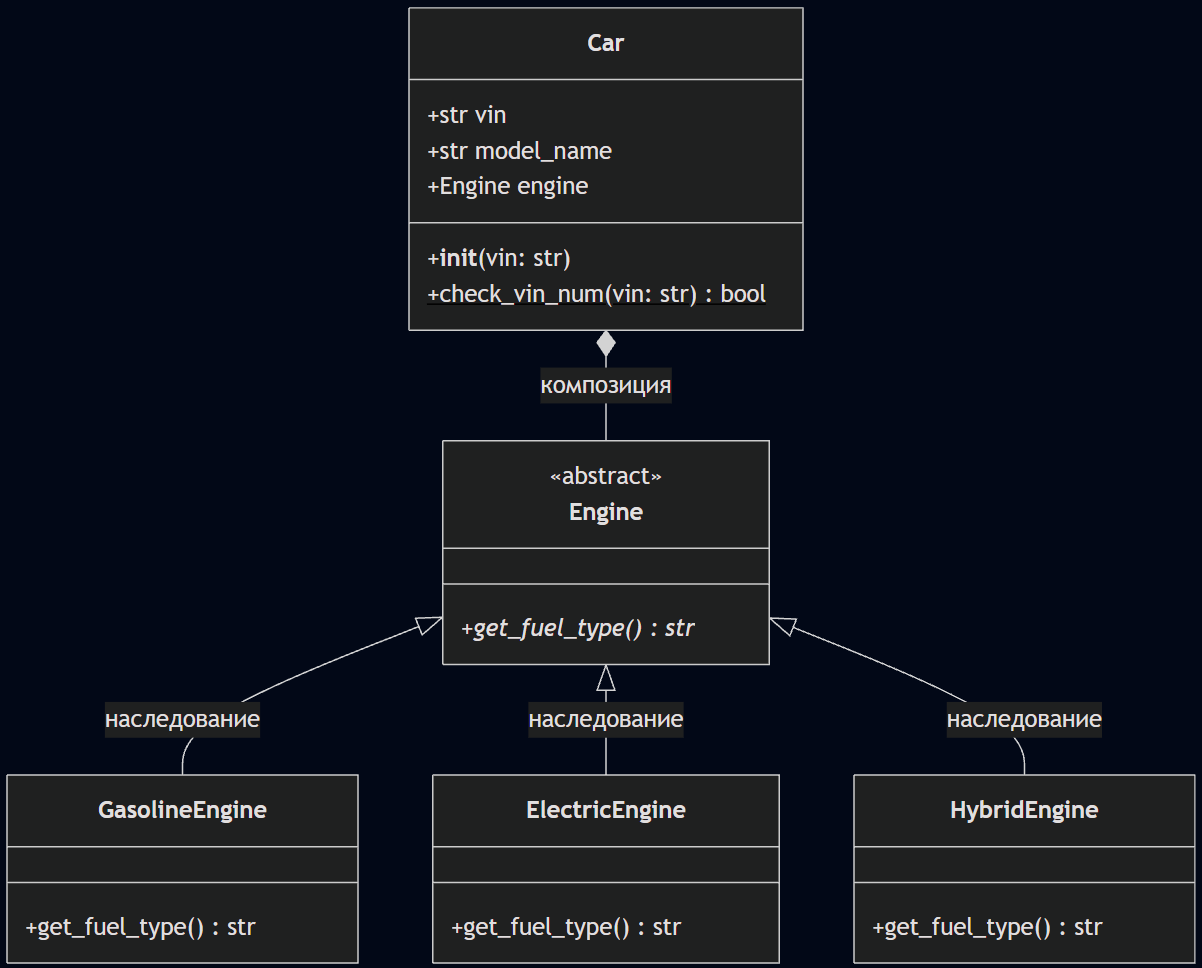

In [4]:
from abc import ABC, abstractmethod

class Engine(ABC):
    @abstractmethod # общая документация для получения типа двигателя
    def get_fuel_type(self) -> str:
        """Возвращает тип двигателя"""
        pass

class GasolineEngine(Engine):
    def get_fuel_type(self) -> str:
        return "Бензиновый"

class ElectricEngine(Engine):
    def get_fuel_type(self) -> str:
        return "Электрический"

class HybridEngine(Engine):
    def get_fuel_type(self) -> str:
        return "Гибрид"

class Car:
    def __init__(self, vin: str):
        if Car.check_vin_num(vin):
            self.vin = vin
            self.model_name = vin[0:5]
            if vin[5] == 'G' or vin[5] == 'g':
                self.engine = GasolineEngine()
            elif vin[5] == 'E' or vin[5] == 'e':
                self.engine = ElectricEngine()
            elif vin[5] == 'H' or vin[5] == 'h':
                self.engine = HybridEngine()
        else:
            raise ValueError("Невалидный VIN")
    # raise для того, что бы сразу выкидывало ошибку и не создавало пустой объект

    @staticmethod # валидация номера с возвратом True False
    def check_vin_num(vin) -> bool:
        """Статический метод для проверки валидации VIN-номера"""
        return len(vin) == 17


tesla = Car("TESLAE12345678901")
print(f"Машина: {tesla.model_name}\nДвигатель: {tesla.engine.get_fuel_type()}")

Машина: TESLA
Двигатель: Электрический


3. Разные способы оплаты (Банковская карта, Электронные деньги) имеют свой расчет комиссии. Общий класс PaymentProcessor использует композицию с TaxCalculator, который вычисляет налог. Статический метод проверяет, является ли сумма допустимой.

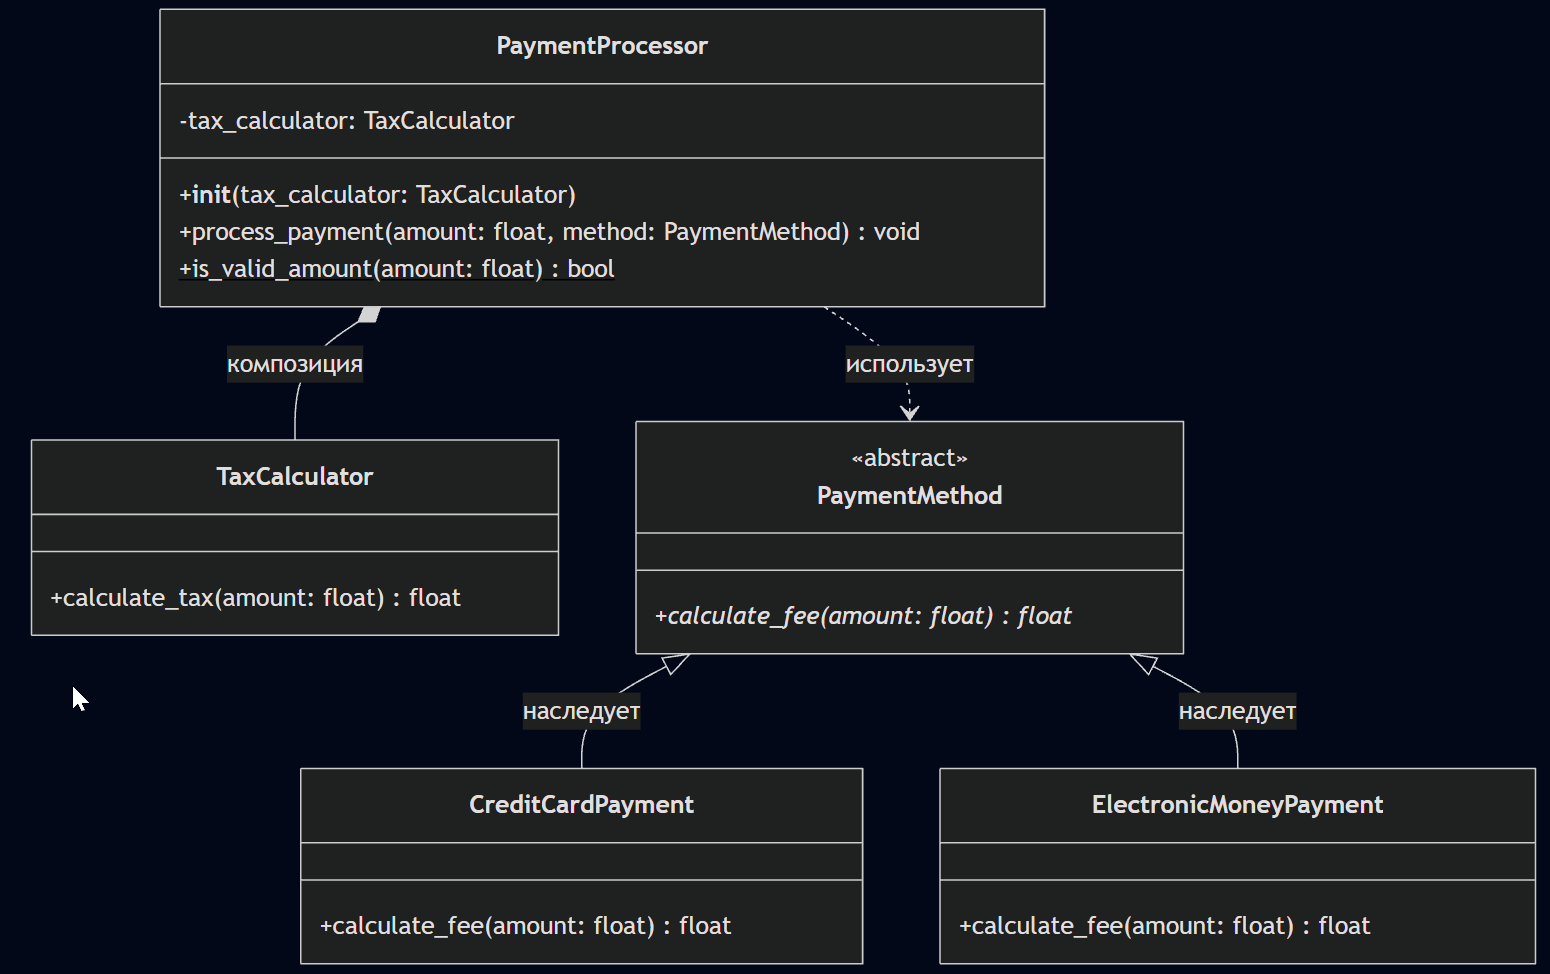

In [11]:
from abc import ABC

class TaxCalculator:
    def calculate_tax(self, amount: float) -> float:
        """Расчёт налога"""
        return amount * 0.13

class PaymentMethod(ABC):
    """Абстракция для способов оплаты"""
    @abstractmethod
    def calculate_fee(self, amount: float) -> float:
        pass

class CreditCard(PaymentMethod):
    """Комиссия для кредитки 2% от суммы"""
    def calculate_fee(self, amount: float) -> float:
        return amount * 0.02

class ElectronicMoney(PaymentMethod):
    """Комиссия для онлайн оплаты 1%"""
    def calculate_fee(self, amount: float) -> float:
        return amount * 0.01

class PaymentProcessor:
    """основной процессор с ипользованием композиции и полиморфизма"""
    def __init__(self, tax_calculator: TaxCalculator):
        self.tax_calculator = tax_calculator

    @staticmethod
    def check_sum(amount: float) -> bool:
        return amount > 0

    def process_payment(self, amount, payment: PaymentMethod) -> float:
        if self.check_sum(amount):
            return amount + payment.calculate_fee(amount) + self.tax_calculator.calculate_tax(amount)
        else:
            raise ValueError('Сумма перевода должна быть больше нуля.')

# создаём объекты калькулятора и процессора
tax_calculat = TaxCalculator()
processor = PaymentProcessor(tax_calculat)
# назначаем сумму перевода и создаем объекты способа перевода
pay_sum = 0
card = CreditCard()
e_money = ElectronicMoney()
# принтуем чек
print(processor.process_payment(pay_sum, card))
print(processor.process_payment(pay_sum, e_money))


ValueError: Сумма перевода должна быть больше нуля.